<a href="https://colab.research.google.com/github/Anjali2000702/LLM/blob/main/LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

GPU Available: True
GPU Name: Tesla T4
Using device: cuda


In [ ]:
# Download VOC 2007 train/val and test

!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

# Extract
!tar -xf VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtest_06-Nov-2007.tar

print("Download and extraction complete!")

tar: VOCtrainval_06-Nov-2007.tar: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
Download and extraction complete!


In [ ]:
# Install kaggle
!pip install -q kaggle

# Upload your kaggle.json file
from google.colab import files
files.upload()

In [ ]:
!pip install -q kaggle

# Create Kaggle folder
!mkdir -p ~/.kaggle

# Upload kaggle.json (download from Kaggle account page)
from google.colab import files
files.upload()

# Move file to correct location
!mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle setup complete")

In [1]:
!pip install torch torchvision opencv-python matplotlib scikit-learn tqdm selectivesearch

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4336 sha256=cec55120d0d41942ad6578eea42c28f6d391fc88a9dd18a74c2a25910a3371a3
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch


# Task
Download the PASCAL VOC 2007 dataset from Kaggle using the Kaggle API.

In [2]:
print("Downloading PASCAL VOC 2007 dataset from Kaggle...")
!kaggle datasets download -d valentynsichkar/pascal-voc-2007
print("Dataset downloaded. Listing files...")
!ls

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Dataset downloaded. Listing files...
sample_data


In [5]:
!pip install torch torchvision opencv-python matplotlib tqdm pycocotools selectivesearch

In [6]:
import os
import requests
import zipfile
from pycocotools.coco import COCO
from tqdm import tqdm

# Create directories
os.makedirs("data/images", exist_ok=True)
os.makedirs("data/annotations", exist_ok=True)

# Download COCO annotations (small file)
ann_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ann_zip = "annotations.zip"

if not os.path.exists(ann_zip):
    print("Downloading annotations...")
    r = requests.get(ann_url)
    open(ann_zip, "wb").write(r.content)

with zipfile.ZipFile(ann_zip, 'r') as zip_ref:
    zip_ref.extractall("data/")

print("Annotations Ready ✅")

Annotations Ready ✅


In [8]:
from pycocotools.coco import COCO

coco = COCO("data/annotations/instances_train2017.json")

# Get category IDs
cat_ids = coco.getCatIds(catNms=["person", "car"])
img_ids = coco.getImgIds(catIds=cat_ids)

# Limit to 200 images
img_ids = img_ids[:200]

print("Selected Images:", len(img_ids))

loading annotations into memory...
Done (t=13.14s)
creating index...
index created!
Selected Images: 200


In [9]:
import requests
from tqdm import tqdm
import os

img_dir = "data/images/train2017"
os.makedirs(img_dir, exist_ok=True)

for img_id in tqdm(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_url = img_info['coco_url']
    img_path = os.path.join(img_dir, img_info['file_name'])

    if not os.path.exists(img_path):
        r = requests.get(img_url)
        with open(img_path, 'wb') as f:
            f.write(r.content)

print("Images Downloaded ✅")

100%|██████████| 200/200 [01:30<00:00,  2.21it/s]

Images Downloaded ✅


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Total Region Proposals: 256


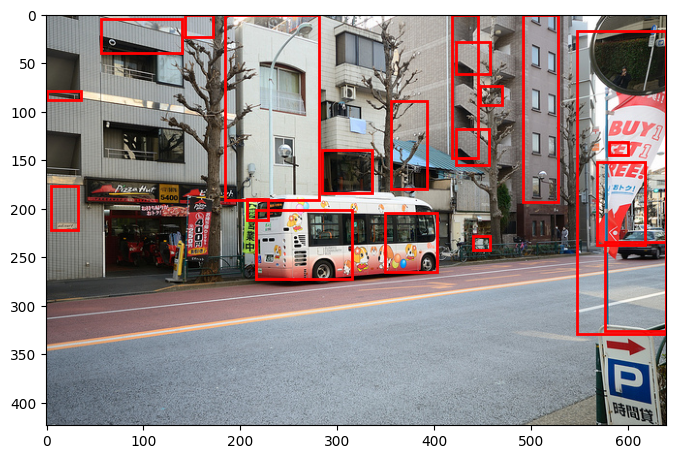

In [10]:
import cv2
import selectivesearch
import matplotlib.pyplot as plt

# Pick one image
img_path = os.path.join(img_dir, os.listdir(img_dir)[0])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run Selective Search
_, regions = selectivesearch.selective_search(image, scale=500, sigma=0.9, min_size=10)

# Extract region proposals
candidates = set()
for r in regions:
    if r['rect'] in candidates:
        continue
    if r['size'] < 200:
        continue
    x, y, w, h = r['rect']
    candidates.add((x, y, w, h))

print("Total Region Proposals:", len(candidates))

# Visualize top 20
fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(image)

for i, (x, y, w, h) in enumerate(list(candidates)[:20]):
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)

plt.show()

Total Region Proposals: 685


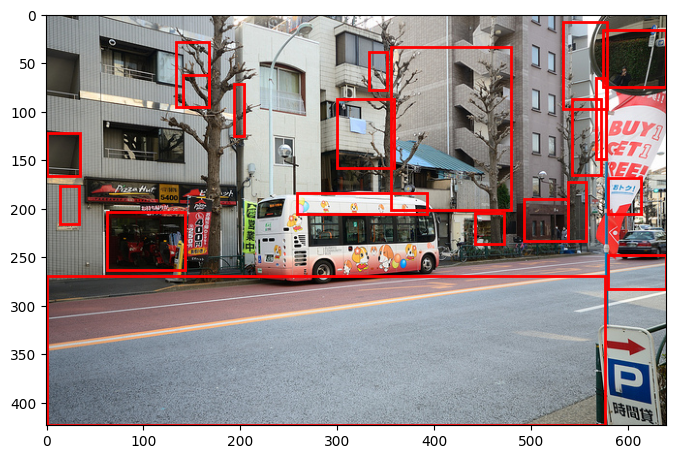

In [11]:
import cv2
import selectivesearch
import matplotlib.pyplot as plt

# Pick one image
img_path = os.path.join(img_dir, os.listdir(img_dir)[0])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run Selective Search (more proposals)
_, regions = selectivesearch.selective_search(
    image,
    scale=100,     # smaller scale → more regions
    sigma=0.8,
    min_size=20
)

candidates = set()
for r in regions:
    if r['rect'] in candidates:
        continue
    x, y, w, h = r['rect']
    if w * h < 500:   # filter very tiny boxes
        continue
    candidates.add((x, y, w, h))

print("Total Region Proposals:", len(candidates))

# Visualize top 20
fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(image)

for i, (x, y, w, h) in enumerate(list(candidates)[:20]):
    rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)

plt.show()

In [12]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained VGG16
vgg = models.vgg16(pretrained=True)

# Remove last classification layer
vgg.classifier = vgg.classifier[:-1]  # remove final FC layer

vgg = vgg.to(device)
vgg.eval()

print("VGG16 Loaded ✅")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 188MB/s]


VGG16 Loaded ✅


In [13]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
import numpy as np

features = []

# Use only first 20 proposals for testing
for (x, y, w, h) in list(candidates)[:20]:
    region = image[y:y+h, x:x+w]

    try:
        input_tensor = transform(region).unsqueeze(0).to(device)

        with torch.no_grad():
            output = vgg(input_tensor)

        features.append(output.cpu().numpy().flatten())
    except:
        continue

print("Extracted Feature Vectors:", len(features))
print("Feature Dimension:", features[0].shape)

Extracted Feature Vectors: 20
Feature Dimension: (4096,)


In [15]:
def compute_iou(boxA, boxB):
    # box format: [x1, y1, x2, y2]

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)

    return iou

print("IoU function ready ✅")

IoU function ready ✅


In [16]:
import numpy as np

# Get annotations for first image
img_id = img_ids[0]
ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
anns = coco.loadAnns(ann_ids)

gt_boxes = []

for ann in anns:
    x, y, w, h = ann['bbox']
    gt_boxes.append([x, y, x+w, y+h])

print("Ground Truth Boxes:", len(gt_boxes))

Ground Truth Boxes: 10


In [17]:
labels = []
region_features = []

for (x, y, w, h) in list(candidates)[:100]:

    proposal_box = [x, y, x+w, y+h]

    max_iou = 0
    for gt in gt_boxes:
        iou = compute_iou(proposal_box, gt)
        if iou > max_iou:
            max_iou = iou

    if max_iou > 0.5:
        labels.append(1)   # Positive
    elif max_iou < 0.3:
        labels.append(0)   # Negative
    else:
        continue           # Ignore

    # Extract feature
    region = image[y:y+h, x:x+w]

    try:
        input_tensor = transform(region).unsqueeze(0).to(device)
        with torch.no_grad():
            output = vgg(input_tensor)
        region_features.append(output.cpu().numpy().flatten())
    except:
        continue

print("Training Samples:", len(region_features))
print("Positive Samples:", sum(labels))
print("Negative Samples:", len(labels)-sum(labels))

Training Samples: 100
Positive Samples: 0
Negative Samples: 100


In [18]:
labels = []
region_features = []

for (x, y, w, h) in list(candidates):

    proposal_box = [x, y, x+w, y+h]

    max_iou = 0
    for gt in gt_boxes:
        iou = compute_iou(proposal_box, gt)
        if iou > max_iou:
            max_iou = iou

    if max_iou > 0.5:
        labels.append(1)
    elif max_iou < 0.3:
        labels.append(0)
    else:
        continue

    region = image[y:y+h, x:x+w]

    try:
        input_tensor = transform(region).unsqueeze(0).to(device)
        with torch.no_grad():
            output = vgg(input_tensor)
        region_features.append(output.cpu().numpy().flatten())
    except:
        continue

print("Training Samples:", len(region_features))
print("Positive Samples:", sum(labels))
print("Negative Samples:", len(labels)-sum(labels))

Training Samples: 681
Positive Samples: 0
Negative Samples: 681


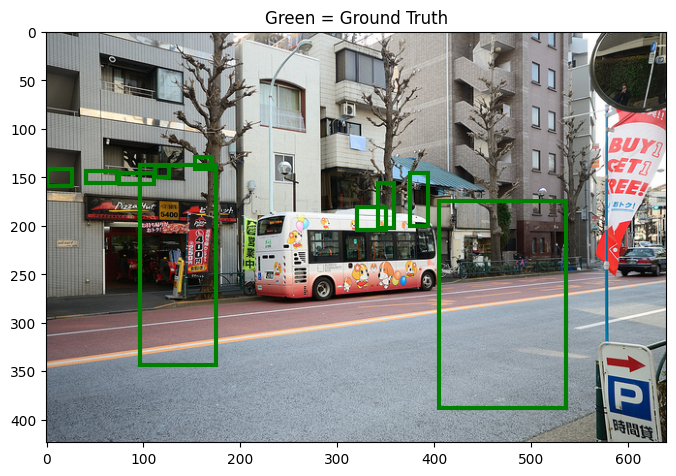

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(image)

for gt in gt_boxes:
    x1, y1, x2, y2 = gt
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                         fill=False, edgecolor='green', linewidth=3)
    ax.add_patch(rect)

plt.title("Green = Ground Truth")
plt.show()

In [20]:
max_iou_overall = 0

for (x, y, w, h) in list(candidates):
    proposal_box = [x, y, x+w, y+h]

    for gt in gt_boxes:
        iou = compute_iou(proposal_box, gt)
        if iou > max_iou_overall:
            max_iou_overall = iou

print("Maximum IoU Found:", max_iou_overall)

Maximum IoU Found: 0.40941291492839366


In [21]:
labels = []
region_features = []

for (x, y, w, h) in list(candidates):

    proposal_box = [x, y, x+w, y+h]

    max_iou = 0
    for gt in gt_boxes:
        iou = compute_iou(proposal_box, gt)
        if iou > max_iou:
            max_iou = iou

    # Updated thresholds
    if max_iou > 0.3:
        labels.append(1)
    elif max_iou < 0.1:
        labels.append(0)
    else:
        continue

    region = image[y:y+h, x:x+w]

    try:
        input_tensor = transform(region).unsqueeze(0).to(device)
        with torch.no_grad():
            output = vgg(input_tensor)
        region_features.append(output.cpu().numpy().flatten())
    except:
        continue

print("Training Samples:", len(region_features))
print("Positive Samples:", sum(labels))
print("Negative Samples:", len(labels)-sum(labels))

Training Samples: 577
Positive Samples: 4
Negative Samples: 573


In [22]:
all_features = []
all_labels = []

num_images = 20   # use first 20 images

for img_index in range(num_images):

    img_id = img_ids[img_index]
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get GT boxes
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)

    gt_boxes = []
    for ann in anns:
        x, y, w, h = ann['bbox']
        gt_boxes.append([x, y, x+w, y+h])

    # Selective Search
    _, regions = selectivesearch.selective_search(
        image, scale=100, sigma=0.8, min_size=20
    )

    candidates = set()
    for r in regions:
        x, y, w, h = r['rect']
        if w*h < 500:
            continue
        candidates.add((x,y,w,h))

    # Label proposals
    for (x, y, w, h) in candidates:

        proposal_box = [x, y, x+w, y+h]

        max_iou = 0
        for gt in gt_boxes:
            iou = compute_iou(proposal_box, gt)
            if iou > max_iou:
                max_iou = iou

        if max_iou > 0.3:
            label = 1
        elif max_iou < 0.1:
            label = 0
        else:
            continue

        region = image[y:y+h, x:x+w]

        try:
            input_tensor = transform(region).unsqueeze(0).to(device)
            with torch.no_grad():
                output = vgg(input_tensor)

            all_features.append(output.cpu().numpy().flatten())
            all_labels.append(label)
        except:
            continue

print("Total Training Samples:", len(all_features))
print("Total Positives:", sum(all_labels))
print("Total Negatives:", len(all_labels)-sum(all_labels))

Total Training Samples: 10597
Total Positives: 603
Total Negatives: 9994
